# Recovery Score Algorithm

**Research Question:** Can we build a simplified recovery score (like Whoop or Oura) using sleep, resting heart rate, and activity data?

**Dataset:** Fitbit Fitness Tracker Data (Kaggle, via Möbius)

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

daily_activity = pd.read_csv('dailyActivity_merged.csv')
sleep_activity = pd.read_csv('sleepDay_merged.csv')
heart_rate = pd.read_csv('heartrate_seconds_merged.csv')

print(daily_activity.shape)
print(sleep_activity.shape)
print(heart_rate.shape)
print(heart_rate.head())
print(heart_rate.dtypes)

(940, 15)
(413, 5)
(2483658, 3)
           Id                  Time  Value
0  2022484408  4/12/2016 7:21:00 AM     97
1  2022484408  4/12/2016 7:21:05 AM    102
2  2022484408  4/12/2016 7:21:10 AM    105
3  2022484408  4/12/2016 7:21:20 AM    103
4  2022484408  4/12/2016 7:21:25 AM    101
Id        int64
Time     object
Value     int64
dtype: object


## 2. Aggregate Heart Rate to Daily Resting HR

In [3]:
heart_rate['Time'] = pd.to_datetime(heart_rate['Time'], format = '%m/%d/%Y %I:%M:%S %p')

heart_rate['Date'] = heart_rate['Time'].dt.date

resting_hr = heart_rate.groupby(['Id', 'Date'])['Value'].quantile(0.05).reset_index()
resting_hr = resting_hr.rename(columns={'Value': 'RestingHR'})

print(resting_hr.shape)
print(resting_hr.head())

(334, 3)
           Id        Date  RestingHR
0  2022484408  2016-04-12       58.0
1  2022484408  2016-04-13       59.0
2  2022484408  2016-04-14       55.0
3  2022484408  2016-04-15       61.0
4  2022484408  2016-04-16       56.0


## 3. Merge Activity, Sleep, and Heart Rate Data

In [4]:

daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'], format='%m/%d/%Y')
sleep_activity['SleepDay'] = pd.to_datetime(sleep_activity['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')
sleep_activity['SleepDay'] = sleep_activity['SleepDay'].dt.normalize()

merged = pd.merge(
    daily_activity,
    sleep_activity,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'SleepDay'],
    how='inner'
)
merged = merged.drop(columns=['SleepDay'])
merged = merged.drop_duplicates(subset=['Id', 'ActivityDate'])

resting_hr['Date'] = pd.to_datetime(resting_hr['Date'])

merged = pd.merge(
    merged,
    resting_hr,
    left_on=['Id', 'ActivityDate'],
    right_on=['Id', 'Date'],
    how='inner'
)
merged = merged.drop(columns=['Date'])

print(merged.shape)
print(merged.head())

(181, 19)
           Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0  2026352035   2016-04-17         838           0.52             0.52   
1  2026352035   2016-04-25        6017           3.73             3.73   
2  2026352035   2016-05-02        7018           4.35             4.35   
3  2026352035   2016-05-09       10685           6.62             6.62   
4  2347167796   2016-04-13       10352           7.01             7.01   

   LoggedActivitiesDistance  VeryActiveDistance  ModeratelyActiveDistance  \
0                       0.0                0.00                      0.00   
1                       0.0                0.00                      0.00   
2                       0.0                0.00                      0.00   
3                       0.0                0.00                      0.00   
4                       0.0                1.66                      1.94   

   LightActiveDistance  SedentaryActiveDistance  VeryActiveMinutes  \
0           

## 4. Build the Recovery Score Formula

In [5]:
def normalize(series, invert=False):
    min_val = series.min()
    max_val = series.max()
    normalized = (series - min_val) / (max_val - min_val) * 100
    if invert:
        normalized = 100 - normalized
    return normalized

merged['SleepScore'] = normalize(merged['TotalMinutesAsleep'])
merged['RHRScore'] = normalize(merged['RestingHR'], invert=True)
merged['SedentaryScore'] = normalize(merged['SedentaryMinutes'], invert=True)

merged['RecoveryScore'] = (
    merged['SleepScore'] * 0.50 +
    merged['RHRScore'] * 0.35 +
    merged['SedentaryScore'] * 0.15
)

print(merged[['Id', 'ActivityDate', 'TotalMinutesAsleep', 'RestingHR', 'SedentaryMinutes', 'RecoveryScore']].head(10))
print(merged['RecoveryScore'].describe())

           Id ActivityDate  TotalMinutesAsleep  RestingHR  SedentaryMinutes  \
0  2026352035   2016-04-17                 437      64.55              1053   
1  2026352035   2016-04-25                 506      88.00               821   
2  2026352035   2016-05-02                 511      73.00               716   
3  2026352035   2016-05-09                 531      83.50               543   
4  2347167796   2016-04-13                 467      61.00               676   
5  2347167796   2016-04-14                 445      61.00               705   
6  2347167796   2016-04-15                 452      61.00               720   
7  2347167796   2016-04-17                 556      63.00               508   
8  2347167796   2016-04-18                 500      59.00               678   
9  2347167796   2016-04-19                 465      59.00               648   

   RecoveryScore  
0      46.746325  
1      36.171611  
2      49.477936  
3      44.833019  
4      56.234733  
5      54.344005

## 5. Validate the Formula

In [6]:
print("Best recovery days:")
print(merged.nlargest(5, 'RecoveryScore')[['Id', 'ActivityDate', 'TotalMinutesAsleep', 'RestingHR', 'SedentaryMinutes', 'RecoveryScore']])

print("\nWorst recovery days:")
print(merged.nsmallest(5, 'RecoveryScore')[['Id', 'ActivityDate', 'TotalMinutesAsleep', 'RestingHR', 'SedentaryMinutes', 'RecoveryScore']])

Best recovery days:
             Id ActivityDate  TotalMinutesAsleep  RestingHR  SedentaryMinutes  \
73   5553957443   2016-04-30                 775       59.0               506   
91   5577150313   2016-04-17                 549       43.0               525   
63   5553957443   2016-04-20                 658       52.0               598   
108  5577150313   2016-05-04                 603       47.0               631   
41   4388161847   2016-05-01                 547       45.0               579   

     RecoveryScore  
73       81.358834  
91       77.809561  
63       77.513135  
108      77.160861  
41       75.450601  

Worst recovery days:
             Id ActivityDate  TotalMinutesAsleep  RestingHR  SedentaryMinutes  \
20   4020332650   2016-04-16                  77       68.0              1222   
164  7007744171   2016-04-16                  79       67.0              1155   
165  7007744171   2016-05-01                  58       65.0              1142   
51   4558609924   201

## 6. Score Distribution

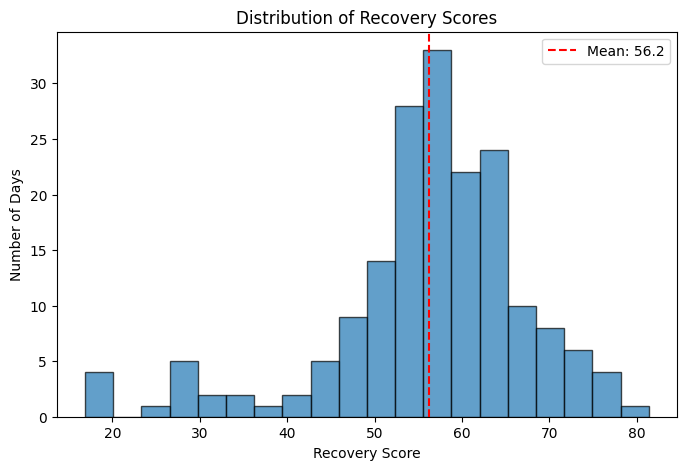

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(merged['RecoveryScore'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Recovery Score')
plt.ylabel('Number of Days')
plt.title('Distribution of Recovery Scores')
plt.axvline(merged['RecoveryScore'].mean(), color='red', linestyle='--', label=f"Mean: {merged['RecoveryScore'].mean():.1f}")
plt.legend()
plt.savefig('recovery_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confirm All Inputs Contribute

In [8]:
print(merged[['RecoveryScore', 'SleepScore', 'RHRScore', 'SedentaryScore']].corr()['RecoveryScore'])

RecoveryScore     1.000000
SleepScore        0.876566
RHRScore          0.543874
SedentaryScore    0.676764
Name: RecoveryScore, dtype: float64


## 8. Interactive Recovery Score Function

In [9]:
def get_recovery_category(score):
    if score >= 65:
        return "Excellent"
    elif score >= 45:
        return "Good"
    elif score >= 25:
        return "Fair"
    else:
        return "Poor"

def calculate_recovery_score(sleep_minutes, resting_hr, sedentary_minutes, reference_df=merged):
    sleep_score = (sleep_minutes - reference_df['TotalMinutesAsleep'].min()) / \
                  (reference_df['TotalMinutesAsleep'].max() - reference_df['TotalMinutesAsleep'].min()) * 100

    rhr_score = 100 - ((resting_hr - reference_df['RestingHR'].min()) / \
                (reference_df['RestingHR'].max() - reference_df['RestingHR'].min()) * 100)

    sedentary_score = 100 - ((sedentary_minutes - reference_df['SedentaryMinutes'].min()) / \
                      (reference_df['SedentaryMinutes'].max() - reference_df['SedentaryMinutes'].min()) * 100)

    recovery_score = round(sleep_score * 0.50 + rhr_score * 0.35 + sedentary_score * 0.15, 1)
    category = get_recovery_category(recovery_score)

    return recovery_score, category


for label, sleep, rhr, sedentary in [
    ("Great recovery day", 480, 52, 400),
    ("Poor recovery day", 200, 75, 900),
    ("Average day", 400, 62, 700)
]:
    score, category = calculate_recovery_score(sleep, rhr, sedentary)
    print(f"{label}: {score} ({category})")

Great recovery day: 67.5 (Excellent)
Poor recovery day: 24.0 (Poor)
Average day: 50.5 (Good)
